In [ ]:
import os
os.environ["GOOGLE_MAPS_API_KEY"] = "YOUR-API-KEY"

import geopandas as gpd
import ee
import json
import geemap
import matplotlib.pyplot as plt
import numpy as np

c:\Users\jcahi\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\jcahi\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
c:\Users\jcahi\anaconda3\lib\site-packages\google\oauth2\__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
c:\Users\jcahi\anaconda3\lib\site-packages\google\auth\__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. G

In [2]:
# authentication
ee.Authenticate()
ee.Initialize(project='deep-learning-detroit')

In [6]:
# Load study area from geopackage
grid_gdf = gpd.read_file(r'C:\Users\jcahi\OneDrive\Desktop\5080\650_group\musa-650-spring2026\assignments\final_project_files\data\detroit_tile_grid.gpkg')

print(f'CRS: {grid_gdf.crs}')
print(f'Number of features: {len(grid_gdf)}')
print(f'Geometry types: {grid_gdf.geometry.type.unique()}')
print(grid_gdf.head())

CRS: EPSG:32617
Number of features: 2484
Geometry types: ['Polygon']
   tile_id                                           geometry
0        0  POLYGON ((325815.289 4688101.959, 325815.289 4...
1        1  POLYGON ((325815.289 4688255.559, 325815.289 4...
2        2  POLYGON ((325815.289 4688409.159, 325815.289 4...
3        3  POLYGON ((325815.289 4688562.759, 325815.289 4...
4        4  POLYGON ((325815.289 4688716.359, 325815.289 4...


In [7]:
# Convert study area to EE geometry
# Reproject to WGS84 if needed (EE requires 4326)
grid_gdf_wgs84 = grid_gdf.to_crs('EPSG:4326')[['geometry']]
geojson_dict = json.loads(grid_gdf_wgs84.to_json())

# If single feature
if len(geojson_dict['features']) == 1:
    study_area_ee = ee.Geometry(geojson_dict['features'][0]['geometry'])
else:
    # Dissolve multiple features into one geometry
    geometries = [ee.Geometry(f['geometry']) for f in geojson_dict['features']]
    study_area_ee = ee.Geometry.MultiPolygon(
        [g for g in geometries]
    ).dissolve()

print('Study area geometry loaded successfully')

Study area geometry loaded successfully


In [8]:
# Fetch AlphaEarth embeddings for study area
dataset = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")

emb_2018 = dataset.filterDate("2018-01-01", "2019-01-01").filterBounds(study_area_ee).mosaic()
emb_2022 = dataset.filterDate("2022-01-01", "2023-01-01").filterBounds(study_area_ee).mosaic()

print('Embeddings fetched for 2018 and 2022')

Embeddings fetched for 2018 and 2022


In [9]:
# Compute change magnitude between 2018 and 2022
diff = emb_2022.subtract(emb_2018)
change_magnitude = diff.pow(2).reduce(ee.Reducer.sum()).sqrt().clip(study_area_ee)

In [10]:
# Sample change magnitude for summary statistics
sample = change_magnitude.rename('change').sample(
    region=study_area_ee,
    scale=30,
    numPixels=5000,
    seed=42,
    geometries=True
)

df = geemap.ee_to_df(sample)
print(df.head())
print(df.shape)

     change
0  0.300450
1  0.360625
2  0.356914
3  0.241721
4  0.299631
(5013, 1)


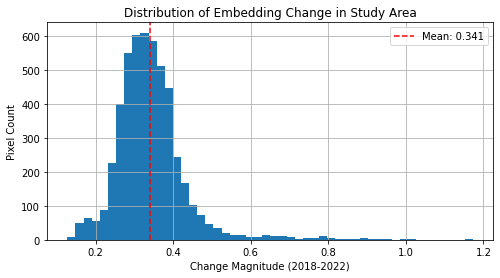

Mean change: 0.3411
Max change:  1.1737
Top 10% threshold: 0.4264


In [11]:
# Distribution of change values
df['change'].hist(bins=50, figsize=(8, 4))
plt.xlabel('Change Magnitude (2018-2022)')
plt.ylabel('Pixel Count')
plt.title('Distribution of Embedding Change in Study Area')
plt.axvline(df['change'].mean(), color='red', linestyle='--', label=f'Mean: {df["change"].mean():.3f}')
plt.legend()
plt.show()

print(f"Mean change: {df['change'].mean():.4f}")
print(f"Max change:  {df['change'].max():.4f}")
print(f"Top 10% threshold: {df['change'].quantile(0.9):.4f}")

In [18]:
# Map of change magnitude over study area
change_map = geemap.Map(basemap="SATELLITE")
change_map.centerObject(study_area_ee, zoom=13)

change_vis = {
    'min': 0,
    'max': 0.5,
    'palette': ['#2166ac', '#f7f7f7', '#d6604d', '#b2182b']
}
change_map.addLayer(change_magnitude, change_vis, 'Embedding Change 2018-2022')

study_area_fc = ee.FeatureCollection([ee.Feature(study_area_ee)])
change_map.addLayer(study_area_fc, {}, 'Study Area Boundary')

change_map.add_colorbar(change_vis, label='Change Magnitude')
change_map

Map(center=[42.35836452427759, -83.06660430997435], controls=(WidgetControl(options=['position', 'transparent_…

In [13]:
# Export GeoTIFFs at native 10m resolution
import os
os.makedirs('data', exist_ok=True)

# Export change magnitude
geemap.ee_export_image(
    change_magnitude.rename('change_magnitude'),
    filename='data/alphaearth_studyarea_10m_change.tif',
    scale=10,
    region=study_area_ee,
    crs='EPSG:4326'
)

# Export full 128-band embeddings (both years) at native resolution
both_years = emb_2018.rename(
    [f'2018_A{str(i).zfill(2)}' for i in range(64)]
).addBands(
    emb_2022.rename(
        [f'2022_A{str(i).zfill(2)}' for i in range(64)]
    )
).clip(study_area_ee)

geemap.ee_export_image(
    both_years,
    filename='data/alphaearth_studyarea_10m_embeddings.tif',
    scale=10,
    region=study_area_ee,
    crs='EPSG:4326'
)

print("Exports complete")

Generating URL ...
Please wait ...
Data downloaded to c:\Users\jcahi\OneDrive\Desktop\5080\650_group\musa-650-spring2026\assignments\final_project_files\data\alphaearth_studyarea_10m_change.tif
Generating URL ...
An error occurred while downloading.
Total request size (962899200 bytes) must be less than or equal to 50331648 bytes.
Exports complete


In [21]:
# Cluster on full 2022 embeddings (64 dims) instead of change magnitude
training_emb = emb_2022.sample(
    region=study_area_ee,
    scale=10,
    numPixels=5000,
    seed=42
)

clusterer_emb = ee.Clusterer.wekaKMeans(5).train(training_emb)
clustered_2018 = emb_2018.cluster(clusterer_emb).clip(study_area_ee)
clustered_2022 = emb_2022.cluster(clusterer_emb).clip(study_area_ee)

# Where did cluster labels change between years?
cluster_change = clustered_2022.subtract(clustered_2018).neq(0).clip(study_area_ee)

In [22]:
# map of kmeans clusters on full embeddings

cluster_vis_emb = {
    'min': 0,
    'max': 4,
    'palette': ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4']
}

change_vis_binary = {
    'min': 0,
    'max': 1,
    'palette': ['white', 'red']
}

k_means_map = geemap.Map()
k_means_map.centerObject(study_area_ee, zoom=13)
k_means_map.add_basemap("SATELLITE")

k_means_map.addLayer(clustered_2018, cluster_vis_emb, 'Clusters 2018')
k_means_map.addLayer(clustered_2022, cluster_vis_emb, 'Clusters 2022')
k_means_map.addLayer(cluster_change, change_vis_binary, 'Pixels That Changed Cluster')

study_area_fc = ee.FeatureCollection([ee.Feature(study_area_ee)])
k_means_map.addLayer(study_area_fc, {}, 'Study Area Boundary')

k_means_map.add_colorbar(cluster_vis_emb, label='Cluster (0-4)')
k_means_map

Map(center=[42.35836452427759, -83.06660430997435], controls=(WidgetControl(options=['position', 'transparent_…

In [15]:
# Get mean change value per cluster to interpret them
means = change_magnitude.rename('change').addBands(clustered.rename('cluster')) \
    .reduceRegion(
        reducer=ee.Reducer.mean().group(groupField=1, groupName='cluster'),
        geometry=study_area_ee,
        scale=10,
        maxPixels=1e9
    ).getInfo()

print(means)

{'groups': [{'cluster': 0, 'mean': 0.28289000804808356}, {'cluster': 1, 'mean': 0.6444699075544524}, {'cluster': 2, 'mean': 0.3837548199868741}]}


In [ ]:
# task = ee.batch.Export.image.toDrive(
#     image=both_years,
#     description='alphaearth_studyarea_10m_embeddings',
#     folder='detroit_embeddings',
#     fileNamePrefix='alphaearth_studyarea_10m_embeddings',
#     region=study_area_ee,
#     scale=10,
#     crs='EPSG:4326',
#     fileFormat='GeoTIFF',
#     maxPixels=1e10
# )
# task.start()

# # Monitor
# import time
# while task.active():
#     print(f"Status: {task.status()['state']}")
#     time.sleep(15)
# print("Done:", task.status()['state'])

Status: READY
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Status: RUNNING
Done: COMPLETED
